In [1]:
import pandas as pd 
df = pd.read_csv('insurance_data.csv')

In [2]:
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


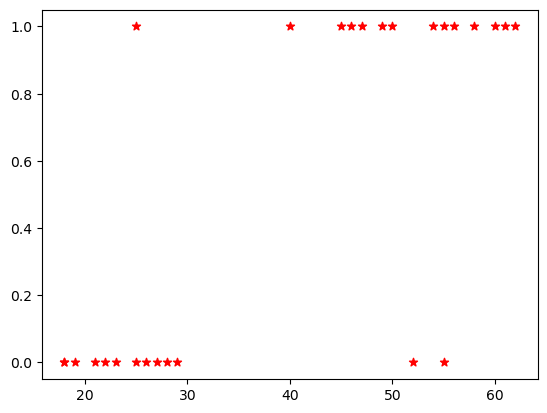

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df.age,df.bought_insurance,marker='*',color='red')
plt.show()

In [7]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               27 non-null     int64
 1   bought_insurance  27 non-null     int64
dtypes: int64(2)
memory usage: 564.0 bytes


,age,bought_insurance
count,27.000000,27.000000
mean,39.666667,0.518519
std,15.745573,0.509175
min,18.000000,0.000000
25%,25.000000,0.000000
50%,45.000000,1.000000
75%,54.500000,1.000000
max,62.000000,1.000000


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.2,random_state=42)

In [9]:
X_test

,age
8,62
13,29
9,61
21,26
0,22
11,28


In [10]:
X_train

,age
16,25
17,58
12,27
24,50
1,25
4,46
5,56
2,47
15,55
22,40


In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [12]:
model.predict(X_test)


array([1, 0, 1, 0, 0, 0])

In [13]:
model.predict_proba(X_test)
model.score(X_test,y_test)

1.0

In [14]:
model.predict_proba(X_test)

array([[0.05428672, 0.94571328],
       [0.7055532 , 0.2944468 ],
       [0.06039333, 0.93960667],
       [0.77084966, 0.22915034],
       [0.84096469, 0.15903531],
       [0.72848723, 0.27151277]])

Exercise
Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics.

Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)

Plot bar charts showing impact of employee salaries on retention

Plot bar charts showing corelation between department and employee retention

Now build logistic regression model using variables that were narrowed down in step 1

Measure the accuracy of the model

In [17]:
import pandas as pd 
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['salary']= le.fit_transform(df['salary'])


In [19]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,1
1,0.80,0.86,5,262,6,0,1,0,sales,2
2,0.11,0.88,7,272,4,0,1,0,sales,2
3,0.72,0.87,5,223,5,0,1,0,sales,1
4,0.37,0.52,2,159,3,0,1,0,sales,1


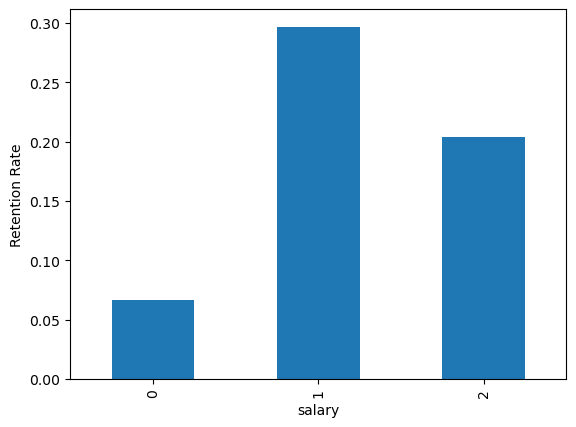

In [25]:
#Salary vs Retention
salary_retention = df.groupby(df['salary'])['left'].mean()
salary_retention.plot(kind='bar')
plt.ylabel('Retention Rate')
plt.show()

In [21]:
df['Department'].value_counts()


Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [22]:
le2 = LabelEncoder()
df['Department']= le2.fit_transform(df['Department'])


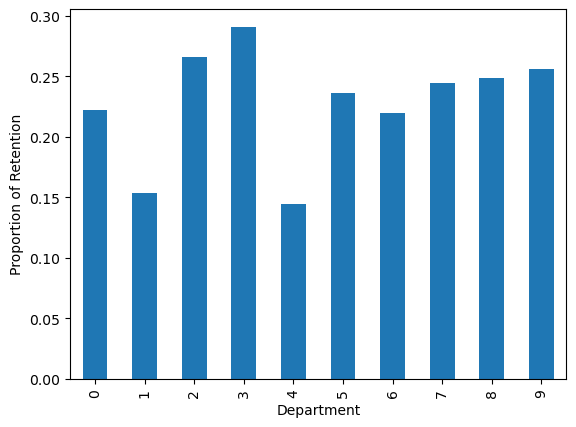

In [26]:
#Department vs Retention
dept_retention = df.groupby(df['Department'])['left'].mean()
dept_retention.plot(kind='bar')
plt.ylabel('Proportion of Retention')
plt.show()


In [28]:
df.groupby('left')[['satisfaction_level','average_montly_hours','time_spend_company','promotion_last_5years']].mean()


,satisfaction_level,average_montly_hours,time_spend_company,promotion_last_5years
left,,,,
0,0.666810,199.060203,3.380032,0.026251
1,0.440098,207.419210,3.876505,0.005321


In [31]:
X = df[['satisfaction_level','average_montly_hours','time_spend_company']]
Y= df['left']

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)


LogisticRegression()

In [32]:
model.predict(X_test)


array([0, 0, 0, ..., 0, 0, 0])

In [33]:
model.predict_proba(X_test)

array([[0.84751926, 0.15248074],
       [0.93668789, 0.06331211],
       [0.86859973, 0.13140027],
       ...,
       [0.89102882, 0.10897118],
       [0.92483741, 0.07516259],
       [0.53274636, 0.46725364]])

In [34]:
model.score(X_test,y_test)

0.748

In [35]:
#One hot encoding 
y= df['left']
x_num = df[['satisfaction_level','last_evaluation','number_project',
            'average_montly_hours','time_spend_company',
            'Work_accident','promotion_last_5years']]
x_cat = pd.get_dummies(df[['salary','Department']],drop_first=True)
x= pd.concat([x_num,x_cat],axis=1)

In [36]:
x.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,Department
0,0.38,0.53,2,157,3,0,0,1,7
1,0.80,0.86,5,262,6,0,0,2,7
2,0.11,0.88,7,272,4,0,0,2,7
3,0.72,0.87,5,223,5,0,0,1,7
4,0.37,0.52,2,159,3,0,0,1,7


In [37]:
#Train test split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)


c:\Users\varsv\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
model.score(X_test,y_test)

0.7573333333333333

In [39]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
y_pred = model.predict(X_test)
print(f"Classification report: \n {classification_report(y_test,y_pred)}")
print(f"Confusion matrix: \n {confusion_matrix(y_test,y_pred)}")

Classification report: 
               precision    recall  f1-score   support

           0       0.79      0.92      0.85      2294
           1       0.47      0.23      0.31       706

    accuracy                           0.76      3000
   macro avg       0.63      0.57      0.58      3000
weighted avg       0.72      0.76      0.72      3000

Confusion matrix: 
 [[2111  183]
 [ 545  161]]


In [40]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000,class_weight='balanced')
model.fit(X_train,y_train)
print(model.score(X_test,y_test))


0.7523333333333333


In [41]:
import numpy as np
y_prob = model.predict_proba(X_test)[:,1]
threshold = 0.3
y_pred_custom = (y_prob>threshold).astype(int)

In [42]:
from sklearn.metrics import classification_report,confusion_matrix
print(f"Classification report: \n {classification_report(y_test,y_pred_custom)}")
print(f"Confusion matrix: \n {confusion_matrix(y_test,y_pred_custom)}")

Classification report: 
               precision    recall  f1-score   support

           0       0.97      0.50      0.66      2294
           1       0.37      0.96      0.54       706

    accuracy                           0.61      3000
   macro avg       0.67      0.73      0.60      3000
weighted avg       0.83      0.61      0.63      3000

Confusion matrix: 
 [[1151 1143]
 [  30  676]]
